In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pykalman import KalmanFilter
import os
from sklearn.cluster import KMeans


In [4]:
#should read in some sort of processed df, exported from exploration analysis notebook. since im not doing it the next cells are just filling in NAs
# df = pd.read_csv('all_data_4pps.csv')

dir_in = 'D:\\arxeia\\AI_VU\\THESIS_internship\\3-experimental\\data\\allSensors_allPPs'
os.chdir(dir_in)
# df = pd.read_csv('all_data_FINAL.csv')

df = pd.read_csv('all_data_final_kalmanFilled.csv')

In [5]:
num_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer', 'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener', 'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
 'AU14_Dimpler','AU15_LipCornerDepressonr', 'AU17_ChinRaiser', 'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart', 'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
 'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp', 'gazeDown', 'gazeRight', 'gazeLeft', 'duration', 'Rclick', 'Lclick', 'move_dist', 'move_duration', 'move_speed',
 'scroll_dur', 'keyPress', 'press_dur', 'backsp', 'backsp_dur', 'pause_dur', 'pause_rate']

feature_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer', 'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener', 'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
 'AU14_Dimpler','AU15_LipCornerDepressonr', 'AU17_ChinRaiser', 'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart', 'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
 'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp', 'gazeDown', 'gazeRight', 'gazeLeft', 'Rclick', 'Lclick', 'keyPress', 'move_dist','move_duration']

# feature_cols = num_cols

ValueError: Supply a 'c' argument or a 'color' kwarg but not both; they differ but their functionalities overlap.

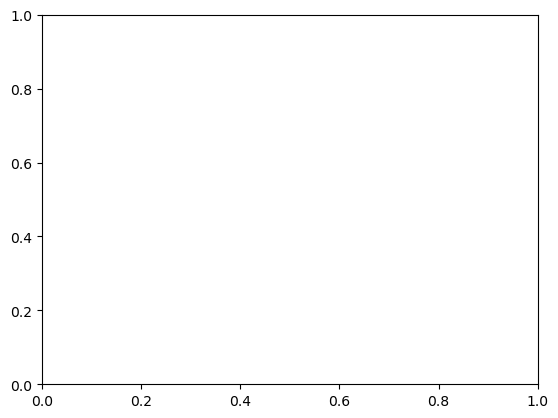

In [8]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans


df_stress = df[df['condition'] == 'S']

# Select the subset of the dataframe for the Neutral condition (N)
df_neutral = df[df['condition'] == 'N']

# Extract the feature values for the Stress condition
# features_stress = df_stress[['feature1', 'feature2']].values
features_stress = df_stress[num_cols].values

# Extract the feature values for the Neutral condition
# features_neutral = df_neutral[['feature1', 'feature2']].values
features_neutral = df_neutral[num_cols].values

# Perform k-means clustering on the feature values for Stress condition
num_clusters = 2  # Specify the number of clusters
kmeans_stress = KMeans(n_clusters=num_clusters)
kmeans_stress.fit(features_stress)
cluster_labels_stress = kmeans_stress.labels_

# Perform k-means clustering on the feature values for Neutral condition
kmeans_neutral = KMeans(n_clusters=num_clusters)
kmeans_neutral.fit(features_neutral)
cluster_labels_neutral = kmeans_neutral.labels_

# Plot the clustering results for Stress condition
plt.scatter(features_stress[:, 0], features_stress[:, 1], c=cluster_labels_stress,  label='Stress', color = 'red')
# Plot the clustering results for Neutral condition
plt.scatter(features_neutral[:, 0], features_neutral[:, 1], c=cluster_labels_neutral,  label='Neutral', color='blue')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clustering of Features')
plt.colorbar()
plt.legend()
plt.show()


In [10]:
cluster_labels_neutral

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

only 1 feature clustering

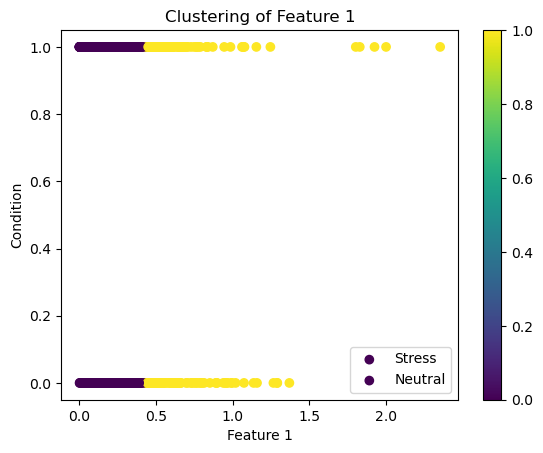

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming you already have a dataframe named 'df' with columns: 'feature1' and 'condition'

# Select the subset of the dataframe for the Stress condition (S)
df_stress = df[df['condition'] == 'S']

# Select the subset of the dataframe for the Neutral condition (N)
df_neutral = df[df['condition'] == 'N']

# Extract the feature1 values for the Stress condition
feature1_stress = df_stress['AU1_InnerBrowRaiser'].values.reshape(-1, 1)

# Extract the feature1 values for the Neutral condition
feature1_neutral = df_neutral['AU1_InnerBrowRaiser'].values.reshape(-1, 1)

# Perform k-means clustering on the feature1 values for Stress condition
num_clusters = 2  # Specify the number of clusters
kmeans_stress = KMeans(n_clusters=num_clusters)
kmeans_stress.fit(feature1_stress)
cluster_labels_stress = kmeans_stress.labels_

# Perform k-means clustering on the feature1 values for Neutral condition
kmeans_neutral = KMeans(n_clusters=num_clusters)
kmeans_neutral.fit(feature1_neutral)
cluster_labels_neutral = kmeans_neutral.labels_

# Plot the clustering results for Stress condition
plt.scatter(feature1_stress, np.zeros(len(feature1_stress)), c=cluster_labels_stress, cmap='viridis', label='Stress')
# Plot the clustering results for Neutral condition
plt.scatter(feature1_neutral, np.ones(len(feature1_neutral)), c=cluster_labels_neutral, cmap='viridis', label='Neutral')

plt.xlabel('Feature 1')
plt.ylabel('Condition')
plt.title('Clustering of Feature 1')
plt.colorbar()
plt.legend()
plt.show()
